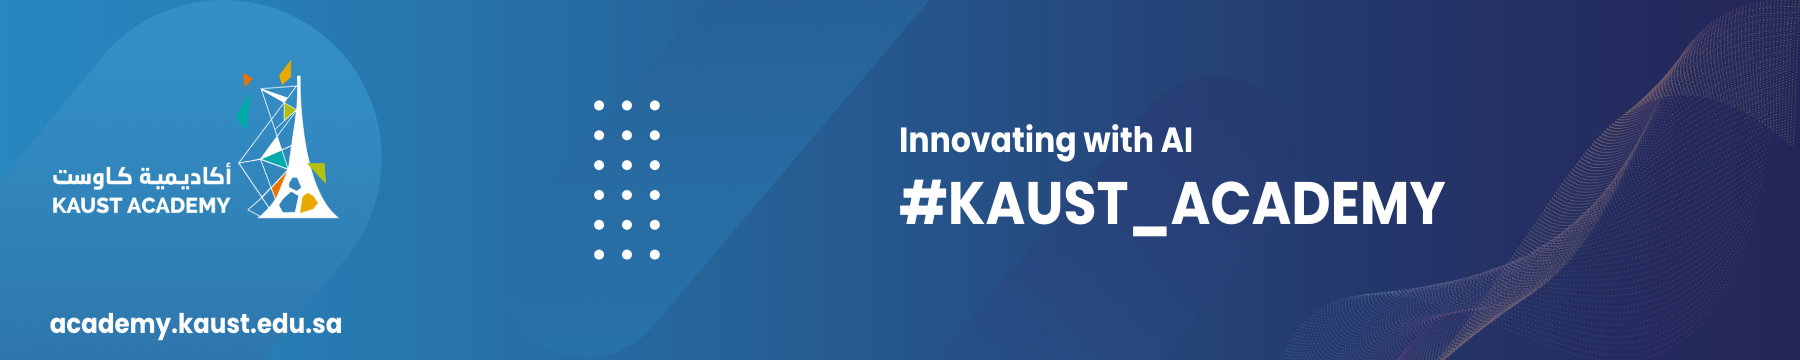

# Multi-Agent Reinforcement Learning

**Multi-Agent Reinforcement Learning (MARL)** is a branch of reinforcement learning in which **multiple agents interact within the same environment and learn how to make decisions**.


However, many real-world systems contain multiple decision-makers, such as:

- Self-driving cars
- Robot teams
- Drone swarms
- Players in games


<div align="center">

<img src="https://onlinelibrary.wiley.com/cms/asset/5f8c0f26-acdd-4de3-b5fd-43c281d1e159/int8845070-fig-0004b-m.png" width="650"/>

*Figure adapted from the survey **Multi-Agent Deep Reinforcement Learning: A Survey** (Gronauer & Diepold, 2022).*

</div>


In [19]:
%pip install -U mpe2 pygame stable_baselines3 supersuit "ray[rllib]" "pettingzoo[mpe]" sb3-contrib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## PettingZoo and the Knights–Archers–Zombies Environment

### What Is PettingZoo?

**PettingZoo** is a Python library designed for **Multi-Agent Reinforcement Learning (MARL)** environments.

It plays a role similar to Gymnasium, but instead of controlling one agent, PettingZoo supports environments containing multiple agents.




**Knights–Archers–Zombies (KAZ)** is a cooperative multi-agent environment from **PettingZoo**.


### Agent Roles

- **Knights** attack nearby zombies using a mace.
- **Archers** attack zombies from a distance using arrows.


| Action | Archer | Knight |
|---:|---|---|
| 0 | Move forward | Move forward |
| 1 | Move backward | Move backward |
| 2 | Turn counterclockwise | Turn counterclockwise |
| 3 | Turn clockwise | Turn clockwise |
| 4 | Fire an arrow | Swing the mace |
| 5 | Do nothing | Do nothing |

### Observation Space
| Entity | Feature 1 | Feature 2 | Feature 3 | Feature 4 | Feature 5 |
|---|---:|---:|---:|---:|---:|
| Archer (self) | 0.12 | -0.45 | 1.00 | 0.00 | 0.25 |
| Archer 1 | -0.30 | 0.18 | 1.00 | 0.00 | 0.12 |
| Archer 2 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| Knight 1 | 0.55 | -0.22 | 0.00 | 1.00 | 0.18 |
| Knight 2 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| Sword 1 | 0.61 | -0.20 | 0.80 | 0.00 | 0.00 |
| Arrow 1 | -0.10 | 0.42 | 0.60 | 0.00 | 0.00 |
| Zombie 1 | 0.78 | -0.51 | -1.00 | 0.50 | 0.35 |
| Zombie 2 | 0.41 | 0.33 | -1.00 | 0.25 | 0.28 |
| ... | ... | ... | ... | ... | ... |
| Entity 27 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |

Zombies are not controlled by the learning model. They:

- Spawn near the top.
- Move automatically toward the bottom.
- Follow unpredictable paths.
- Can kill agents by touching them.
- End the episode if they reach the bottom.

The parameter `max_zombies` controls the maximum number of zombies alive at the same time.

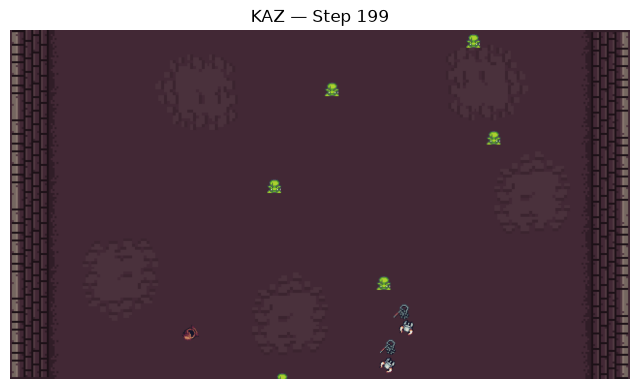

In [20]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from pettingzoo.butterfly import knights_archers_zombies_v10

env = knights_archers_zombies_v10.parallel_env(
    render_mode="rgb_array"
)

observations, infos = env.reset(seed=42)

for step in range(200):
    actions = {
        agent: env.action_space(agent).sample()
        for agent in env.agents
    }

    observations, rewards, terminations, truncations, infos = env.step(actions)

    frame = env.render()

    clear_output(wait=True)
    plt.figure(figsize=(8, 6))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"KAZ — Step {step}")
    plt.show()

    if not env.agents:
        break

env.close()

## Shared-Policy PPO

PPO is an **on-policy actor–critic algorithm**:

* The **actor** selects actions.
* The **critic** estimates state value.
* Training uses recently collected experience.

PPO stabilizes learning by clipping large policy updates:

$$
L^{\text{CLIP}}(\theta)


\mathbb{E}_t
\left[
\min
\left(
r_t(\theta)\hat{A}_t,
\operatorname{clip}
\left(r_t(\theta),1-\epsilon,1+\epsilon\right)\hat{A}_t
\right)
\right]
$$

where:

$$
r_t(\theta)


\frac{\pi_\theta(a_t \mid o_t)}
{\pi_{\theta_{\text{old}}}(a_t \mid o_t)}
$$

In this multi-agent environment, all agents share the same policy:

$$
a_t^i \sim \pi_\theta(a_t^i \mid o_t^i)
$$



In [21]:
from pettingzoo.butterfly import knights_archers_zombies_v10
from stable_baselines3 import PPO
import supersuit as ss
import torch


env = knights_archers_zombies_v10.parallel_env(
    num_archers=2,
    num_knights=2,
    max_zombies=4,
    max_cycles=500,
    vector_state=True,
)

# Keep dead agents using zero observations
env = ss.black_death_v3(env)

# Convert to Stable-Baselines3 format
env = ss.pettingzoo_env_to_vec_env_v1(env)

env = ss.concat_vec_envs_v1(
    env,
    num_vec_envs=1,
    num_cpus=1,
    base_class="stable_baselines3",
)

# Shared PPO model
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

# Train and save
model.learn(
    total_timesteps=100_000,
    progress_bar=True,
)

model.save("ppo_kaz_model")
env.close()


/home/lama/miniconda3/envs/rtx5070/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Using cuda device


/home/lama/miniconda3/envs/rtx5070/lib/python3.11/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


-----------------------------
| time/              |      |
|    fps             | 1470 |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 8192 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1097        |
|    iterations           | 2           |
|    time_elapsed         | 14          |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.009855081 |
|    clip_fraction        | 0.0935      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.78       |
|    explained_variance   | 0.328       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0266      |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0118     |
|    value_loss           | 0.0395      |
-----------------------------------------
----------------------------------

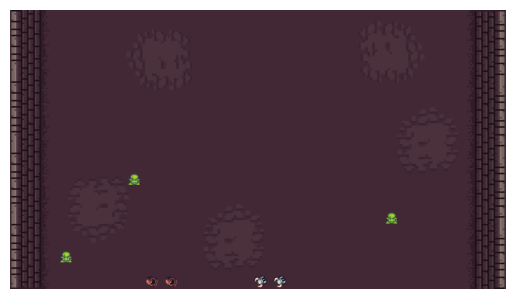

In [22]:
from pettingzoo.butterfly import knights_archers_zombies_v10
import matplotlib.pyplot as plt
from IPython.display import clear_output

env = knights_archers_zombies_v10.parallel_env(
    num_archers=2,
    num_knights=2,
    max_zombies=4,
    vector_state=True,
    render_mode="rgb_array"
)

obs, _ = env.reset()

while env.agents:
    actions = {
        agent: int(model.predict(obs[agent], deterministic=True)[0])
        for agent in env.agents
    }

    obs, rewards, _, _, _ = env.step(actions)

    clear_output(wait=True)
    plt.imshow(env.render())
    plt.axis("off")
    plt.show()

env.close()

##  Separate-Policy PPO

In the previous experiment, a single PPO policy controlled both knights and archers. Since the two agent types have different roles and action semantics, a shared policy may limit specialization.

In this experiment, we train two separate PPO policies:

```text
knight_0, knight_1  → Knight PPO Policy
archer_0, archer_1  → Archer PPO Policy
```

Each policy learns strategies tailored to its corresponding agent type.

In [23]:
import torch
import supersuit as ss
from pettingzoo.butterfly import knights_archers_zombies_v10
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
from ray.tune.registry import register_env


print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


def create_env(config=None):
    env = knights_archers_zombies_v10.parallel_env(
        num_archers=2,
        num_knights=2,
        max_zombies=4,
        max_cycles=500,
        vector_state=True,
    )

    # Convert (21, 5) observation into (105,)
    env = ss.flatten_v0(env)

    return ParallelPettingZooEnv(env)


register_env("kaz", create_env)

temp_env = create_env()

obs_space = temp_env.observation_space["knight_0"]
act_space = temp_env.action_space["knight_0"]

temp_env.close()


def policy_mapping(agent_id, *args, **kwargs):
    if agent_id.startswith("knight"):
        return "knight_policy"

    return "archer_policy"


config = (
    PPOConfig()
    .environment("kaz")
    .framework("torch")

    # Environment runs locally
    .env_runners(num_env_runners=0)

    # Train PPO neural networks on one GPU
    .learners(
        num_learners=0,
        num_gpus_per_learner=1,
    )

    .multi_agent(
        policies={
            "knight_policy": (
                None,
                obs_space,
                act_space,
                {},
            ),
            "archer_policy": (
                None,
                obs_space,
                act_space,
                {},
            ),
        },
        policy_mapping_fn=policy_mapping,
        policies_to_train=[
            "knight_policy",
            "archer_policy",
        ],
    )
)


model = config.build_algo()


for i in range(20):
    result = model.train()
    print(f"Iteration {i + 1} finished")


checkpoint = model.save()
print("Saved at:", checkpoint)

/home/lama/miniconda3/envs/rtx5070/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-30 11:08:06,156	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
I0000 00:00:1785395286.396679  882511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785395287.538937  882511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


2026-07-30 11:08:11,143	INFO worker.py:2024 -- Started a local Ray instance.
2026-07-30 11:08:11,988	WARNING rl_module.py:463 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
2026-07-30 11:08:12,424	WARNING util.py:62 -- Install gputil for GPU system monitoring.


Iteration 1 finished
Iteration 2 finished
Iteration 3 finished
Iteration 4 finished
Iteration 5 finished
Iteration 6 finished
Iteration 7 finished
Iteration 8 finished
Iteration 9 finished
Iteration 10 finished
Iteration 11 finished
Iteration 12 finished
Iteration 13 finished
Iteration 14 finished
Iteration 15 finished
Iteration 16 finished
Iteration 17 finished
Iteration 18 finished
Iteration 19 finished
Iteration 20 finished
Saved at: TrainingResult(checkpoint=Checkpoint(filesystem=local, path=/tmp/tmpe_9z_wk2), metrics={'timers': {'training_iteration': 28.949644157641494, 'restore_env_runners': 1.0519516222631865e-05, 'training_step': 28.94940910871751, 'env_runner_sampling_timer': 14.77777594847315, 'learner_update_timer': 14.168347513443397, 'synch_weights': 0.0026485088768697994, 'synch_env_connectors': 2.734482008335281e-05}, 'env_runners': {'module_to_env_connector': {'connector_pipeline_timer': np.float64(0.0022405363477570692), 'timers': {'connectors': {'get_actions': np.floa

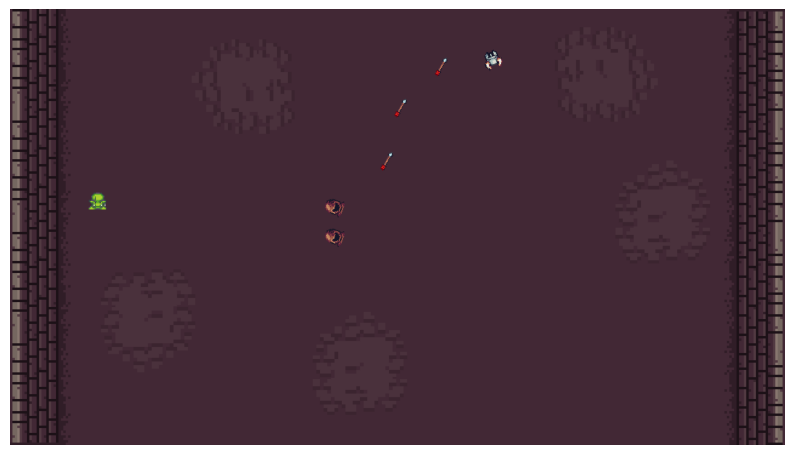

Episode rewards:
archer_0: 2.00
archer_1: 3.00
knight_0: 0.00
knight_1: 2.00


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output
from ray.rllib.core.columns import Columns
from pettingzoo.butterfly import knights_archers_zombies_v10


watch_env = knights_archers_zombies_v10.parallel_env(
    num_archers=2,
    num_knights=2,
    max_zombies=4,
    max_cycles=10000,
    vector_state=True,
    render_mode="rgb_array",
)

observations, infos = watch_env.reset()
# Initialize every agent's accumulated reward to zero
total_rewards = {
    agent: 0.0
    for agent in watch_env.possible_agents
}


while watch_env.agents:

    actions = {}

    for agent in watch_env.agents:

        # Select the correct policy/module
        if agent.startswith("knight"):
            module_id = "knight_policy"
        else:
            module_id = "archer_policy"

        # Get the trained neural network
        module = model.get_module(module_id)

        # Flatten observation: (21, 5) → (105,)
        obs = np.asarray(
            observations[agent],
            dtype=np.float32,
        ).reshape(-1)

        # Find whether the module is on CPU or GPU
        device = next(module.parameters()).device

        # Add batch dimension: (105,) → (1, 105)
        obs_tensor = torch.tensor(
            obs,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        # Run trained policy
        with torch.no_grad():
            output = module.forward_inference(
                {
                    Columns.OBS: obs_tensor
                }
            )

        # PPO returns action logits for the six discrete actions
        logits = output[Columns.ACTION_DIST_INPUTS]

        # Deterministic action: select highest-logit action
        action = torch.argmax(
            logits,
            dim=-1,
        ).item()

        actions[agent] = int(action)

    observations, rewards, terminations, truncations, infos = (
        watch_env.step(actions)
    )

    for agent, reward in rewards.items():
        total_rewards[agent] += reward

    clear_output(wait=True)

    plt.figure(figsize=(10, 6))
    plt.imshow(watch_env.render())
    plt.axis("off")
    plt.show()


watch_env.close()

print("Episode rewards:")

for agent, reward in total_rewards.items():
    print(f"{agent}: {reward:.2f}")

## Competitive Multi-Agent 

In **competitive multi-agent reinforcement learning**, multiple agents interact in the same environment while pursuing conflicting objectives.



Tic-Tac-Toe is a simple **two-player, turn-based, competitive environment**.

- **Agents:** `player_1` and `player_2`
- **Action space:** `Discrete(9)`
- Each action selects one cell on the board.
- Players alternate turns.
- Occupied cells are invalid actions, so an **action mask** is required.
- Typical rewards:
  - `+1` for winning
  - `-1` for losing
  - `0` for a draw

In [25]:
import random
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from pettingzoo.classic import tictactoe_v3
from sb3_contrib import MaskablePPO


class TicTacToeEnv(gym.Env):

    def __init__(self, render_mode=None):
        super().__init__()

        self.env = tictactoe_v3.env(render_mode=render_mode)

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(18,),
            dtype=np.int8
        )

        self.action_space = spaces.Discrete(9)

        self.current_obs = None

    def flatten_obs(self, obs):
        return obs["observation"].reshape(-1).astype(np.int8)

    def action_masks(self):
        return self.current_obs["action_mask"].astype(bool)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.env.reset(seed=seed)

        obs, _, _, _, info = self.env.last()
        self.current_obs = obs

        return self.flatten_obs(obs), info

    def step(self, action):

        # Player 1: learned agent
        self.env.step(int(action))

        obs, _, terminated, truncated, info = self.env.last()

        # Player 1 won or game ended
        if terminated or truncated:
            reward = self.env.rewards["player_1"]

            return (
                np.zeros(18, dtype=np.int8),
                float(reward),
                terminated,
                truncated,
                info
            )

        # Player 2: random agent
        legal_actions = np.flatnonzero(obs["action_mask"])
        random_action = random.choice(legal_actions.tolist())

        self.env.step(random_action)

        obs, _, terminated, truncated, info = self.env.last()

        reward = self.env.rewards["player_1"]

        if terminated or truncated:
            next_obs = np.zeros(18, dtype=np.int8)
        else:
            next_obs = self.flatten_obs(obs)
            self.current_obs = obs

        return (
            next_obs,
            float(reward),
            terminated,
            truncated,
            info
        )

    def render(self):
        return self.env.render()

    def close(self):
        self.env.close()

In [26]:
train_env = TicTacToeEnv(render_mode=None)

model = MaskablePPO(
    "MlpPolicy",
    train_env,
    verbose=1
)

model.learn(total_timesteps=50_000)

model.save("tic_tac_toe_model")

train_env.close()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.19     |
|    ep_rew_mean     | 0.29     |
| time/              |          |
|    fps             | 1045     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4.16         |
|    ep_rew_mean          | 0.29         |
| time/                   |              |
|    fps                  | 774          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0073041404 |
|    clip_fraction        | 0.0585       |
|    clip_range           | 0.2          |
|    e

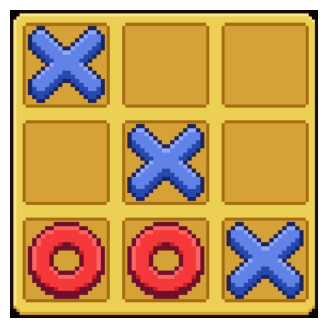

 Learned PPO agent wins!


In [27]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

env = TicTacToeEnv(render_mode="rgb_array")

obs, info = env.reset()

done = False

while not done:

    frame = env.render()

    clear_output(wait=True)

    plt.figure(figsize=(4,4))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

    mask = env.action_masks()

    action, _ = model.predict(
        obs,
        action_masks=mask,
        deterministic=True,
    )

    obs, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    time.sleep(0.8)

# Final board
frame = env.render()

clear_output(wait=True)

plt.figure(figsize=(4,4))
plt.imshow(frame)
plt.axis("off")
plt.show()

if reward > 0:
    print(" Learned PPO agent wins!")
elif reward < 0:
    print(" Random agent wins!")
else:
    print(" Draw!")

env.close()

## Alternating Self-Play

Two separate agents are trained through alternating self-play.

- Player 1 trains against the current fixed policy of Player 2.
- Player 2 then trains against the updated fixed policy of Player 1.
- Only one agent is updated at a time.
- The process is repeated for several rounds.

Keeping the opponent temporarily fixed provides a more stable learning target.

In [28]:
from pettingzoo.classic import tictactoe_v3


class TicTacToeSelfPlay(gym.Env):

    def __init__(self, learner="player_1", opponent=None):
        super().__init__()

        self.learner = learner
        self.opponent = opponent
        self.env = tictactoe_v3.env(render_mode=None)

        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(18,),
            dtype=np.int8,
        )
# Example observation:
# [
#   1, 0,   0, 1,   0, 0,
#   0, 0,   1, 0,   0, 1,
#   0, 0,   0, 0,   1, 0
# ]
#
# Each board position has two values:
# [1, 0] = learner's mark is in this position
# [0, 1] = opponent's mark is in this position
# [0, 0] = this position is empty
        self.action_space = spaces.Discrete(9)
        self.current_obs = None

    def flatten(self, obs):
        return np.asarray(
            obs["observation"],
            dtype=np.int8,
        ).reshape(-1)

    def action_masks(self):
        return np.asarray(
            self.current_obs["action_mask"],
            dtype=bool,
        )

#False, True, False,
 #rue,  False, True,
 #alse, True, True]
    def opponent_move(self, obs):
        mask = np.asarray(
            obs["action_mask"],
            dtype=bool,
        )
 # Legal and illegal actions for the opponent
        if self.opponent is None:
            legal_actions = np.flatnonzero(mask)
            return int(np.random.choice(legal_actions))

        action, _ = self.opponent.predict(
            self.flatten(obs),
            action_masks=mask,
            deterministic=False,
        )

        return int(action)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.env.reset(seed=seed)

        obs, reward, terminated, truncated, info = self.env.last()

        # player_1 must move first
        if self.learner == "player_2":
            first_action = self.opponent_move(obs)
            self.env.step(first_action)

            obs, reward, terminated, truncated, info = self.env.last()

        self.current_obs = obs

        return self.flatten(obs), info

    def step(self, action):

        # Learner moves
        self.env.step(int(action))

        obs, reward, terminated, truncated, info = self.env.last()

        # Game ended after learner's move
        if terminated or truncated:
            learner_reward = -float(reward)

            self.current_obs = None

            return (
                np.zeros(18, dtype=np.int8),
                learner_reward,
                bool(terminated),
                bool(truncated),
                info,
            )

        # Opponent moves
        opponent_action = self.opponent_move(obs)
        self.env.step(opponent_action)

        # Back to learner's turn
        obs, reward, terminated, truncated, info = self.env.last()

        learner_reward = float(reward)

        if terminated or truncated:
            next_obs = np.zeros(18, dtype=np.int8)
            self.current_obs = None
        else:
            next_obs = self.flatten(obs)
            self.current_obs = obs

        return (
            next_obs,
            learner_reward,
            bool(terminated),
            bool(truncated),
            info,
        )

    def close(self):
        self.env.close()

In [29]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training device:", device)

player_1 = MaskablePPO(
    "MlpPolicy",
    env_1,
    verbose=1,
    device=device
)

player_2 = MaskablePPO(
    "MlpPolicy",
    env_2,
    verbose=1,
    device=device
)

Training device: cuda
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [30]:
rounds = 10
steps_per_round = 10_000

for round_number in range(rounds):

    # Train player 1 against the current player 2
    env_1.opponent = player_2

    player_1.learn(
        total_timesteps=steps_per_round,
        reset_num_timesteps=False,
    )

    # Train player 2 against the newly updated player 1
    env_2.opponent = player_1

    player_2.learn(
        total_timesteps=steps_per_round,
        reset_num_timesteps=False,
    )

    print(f"Round {round_number + 1}/{rounds} completed")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4.08     |
|    ep_rew_mean     | 0.1      |
| time/              |          |
|    fps             | 651      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4.06         |
|    ep_rew_mean          | 0.36         |
| time/                   |              |
|    fps                  | 552          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0073861363 |
|    clip_fraction        | 0.0645       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.6         |
|    explained_variance   | -0.13        |
|    learning_r

In [31]:
import numpy as np
from pettingzoo.classic import tictactoe_v3

games = 100

player_1_wins = 0
player_2_wins = 0
draws = 0

for game in range(games):

    env = tictactoe_v3.env(render_mode="rgb_array")
    env.reset(seed=game)

    final_rewards = {
        "player_1": 0.0,
        "player_2": 0.0,
    }

    for agent in env.agent_iter():

        obs, reward, terminated, truncated, info = env.last()

        if terminated or truncated:
            final_rewards[agent] = float(reward)
            action = None

        else:
            state = np.asarray(
                obs["observation"],
                dtype=np.float32,
            ).reshape(-1)

            mask = np.asarray(
                obs["action_mask"],
                dtype=bool,
            )

            model = player_1 if agent == "player_1" else player_2

            action, _ = model.predict(
                state,
                action_masks=mask,
                deterministic=False,
            )

            action = int(action)

        env.step(action)

    env.close()

    r1 = final_rewards["player_1"]
    r2 = final_rewards["player_2"]

    if r1 > r2:
        player_1_wins += 1
    elif r2 > r1:
        player_2_wins += 1
    else:
        draws += 1

print("Games:", games)
print("Player 1 wins:", player_1_wins)
print("Player 2 wins:", player_2_wins)
print("Draws:", draws)

print(f"Player 1 win rate: {player_1_wins / games:.1%}")
print(f"Player 2 win rate: {player_2_wins / games:.1%}")
print(f"Draw rate: {draws / games:.1%}")

Games: 100
Player 1 wins: 77
Player 2 wins: 12
Draws: 11
Player 1 win rate: 77.0%
Player 2 win rate: 12.0%
Draw rate: 11.0%


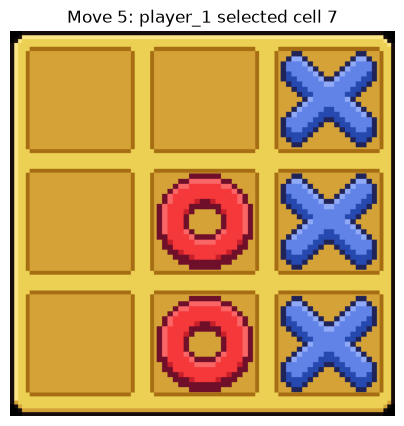

Result: Player 1 wins
Player 1 reward: 1.0
Player 2 reward: -1.0


In [32]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from pettingzoo.classic import tictactoe_v3

# Create a separate environment only for visualization
watch_env = tictactoe_v3.env(render_mode="rgb_array")
watch_env.reset(seed=10)

final_rewards = {
    "player_1": 0.0,
    "player_2": 0.0,
}

move_number = 0

for agent in watch_env.agent_iter():

    obs, reward, terminated, truncated, info = watch_env.last()

    if terminated or truncated:
        final_rewards[agent] = float(reward)
        action = None

    else:
        # Convert the board from (3, 3, 2) into (18,)
        state = np.asarray(
            obs["observation"],
            dtype=np.float32,
        ).reshape(-1)

        # Legal empty positions
        mask = np.asarray(
            obs["action_mask"],
            dtype=bool,
        )

        # Select the model belonging to the current player
        model = player_1 if agent == "player_1" else player_2

        action, _ = model.predict(
            state,
            action_masks=mask,
            deterministic=True,
        )

        action = int(action)
        move_number += 1

    # Execute the selected move
    watch_env.step(action)

    # Display the board after a valid move
    if action is not None:
        frame = watch_env.render()

        clear_output(wait=True)

        plt.figure(figsize=(5, 5))
        plt.imshow(frame)
        plt.title(
            f"Move {move_number}: {agent} selected cell {action}"
        )
        plt.axis("off")
        plt.show()

        time.sleep(1)

watch_env.close()

# Determine the final result
r1 = final_rewards["player_1"]
r2 = final_rewards["player_2"]

if r1 > r2:
    result = "Player 1 wins"
elif r2 > r1:
    result = "Player 2 wins"
else:
    result = "Draw"

print("Result:", result)
print("Player 1 reward:", r1)
print("Player 2 reward:", r2)

**Contributed by: Lama**